In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *
from src.simulate_nmf import simulate_dataset

## N-FINDR
from src.NFINDR import nfindr_BJ

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# setting
K = 3
J = 8
n_reps = 50

# path 
outdir = Path("results/sims")
outdir.mkdir(parents=True, exist_ok=True)

In [6]:
# sample size 
n_list = [100, 300, 1500, 10000, 100000, 500000]

# nonseparable noise strengths
tau_list = [0.0, 0.1, 0.3, 0.6]

# log-error scales
sigma_u = 0.3   # sample-level multiplicative error
sigma_v = 0.3   # variable-level multiplicative error

In [7]:
# # log e_ij = u_i + v_j + tau*eta_ij
# # tau = 0: exactly separable; small tau > 0: weakly separable; large tau > 0: strongly nonseparable 
# # Y_ij = e_ij*Yhat_ij
# # u_i = log a_i; v_j = log b_j 
# # assume E(a_i) = 1
# # u_i = log a_i ~ N(-sigma_u^2/2, sigma_u^2)
# # v_j ~ N(0, sigma_v^2)
# # eta_ij ~ N(0,1)

# def add_log_multiplicative_error(
#     Yhat,
#     sigma_u=0.3,
#     sigma_v=0.3,
#     tau=0.0,
#     seed=None,
# ):
#     """
#     Generate observed data under
#         log eps_ij = u_i + v_j + tau * eta_ij
#         Y_obs_ij   = eps_ij * Yhat_ij
#     """
#     rng = np.random.default_rng(seed)
#     n, J = Yhat.shape

#     mu_u = -0.5 * sigma_u**2 
    
#     u = rng.normal(loc=mu_u, scale=sigma_u, size=n)
#     v = rng.normal(loc=0.0, scale=sigma_v, size=J)
#     eta = rng.normal(loc=0.0, scale=1.0, size=(n, J))

#     log_eps = u[:, None] + v[None, :] + tau * eta
#     eps = np.exp(log_eps)
#     Y_obs = Yhat * eps

#     return Y_obs, eps, u, v, eta

In [5]:
# # container to hold *all* results in memory
# # results[n][tau] 
# results = {}

# for n in n_list:
#     print(f"\n=== Running experiments for n = {n} ===\n")
#     results[n] = {}

#     for tau in tau_list:
#         print(f"\n--- Running experiments for n = {n}, tau = {tau} ---\n")
    
#         # allocate per-(n,tau) arrays
#         per_nt = {
#             # time
#             "time_sourceXray": np.zeros(n_reps),
#             "time_nfindr": np.zeros(n_reps),

#             # H metrics
#             "H_rmssad_sourceXray": np.zeros(n_reps),
#             "H_fro_sourceXray": np.zeros(n_reps),
#             "H_nrmse_sourceXray": np.zeros(n_reps),
#             "H_rmssad_nfindr": np.zeros(n_reps),
#             "H_fro_nfindr": np.zeros(n_reps),
#             "H_nrmse_nfindr": np.zeros(n_reps),

#             # C metrics
#             "C_fro_sourceXray": np.zeros(n_reps),
#             "C_nrmse_sourceXray": np.zeros(n_reps),
#             "C_fro_nfindr": np.zeros(n_reps),
#             "C_nrmse_nfindr": np.zeros(n_reps),
#         }

#         est_per_nt = {
#             "C_hat_sourceXray": np.empty((n_reps, J, K), dtype=float),
#             "C_hat_nfindr": np.empty((n_reps, J, K), dtype=float),
#             "H_star_hat_sourceXray": np.empty((n_reps, K, J), dtype=float),
#             "H_star_hat_nfindr": np.empty((n_reps, K, J), dtype=float),

#             # truths
#             "C": np.empty((n_reps, J, K), dtype=float),
#             "H_star": np.empty((n_reps, K, J), dtype=float),
#         }

#         for rep in range(n_reps):
#             print(f"n={n}, tau={tau}, rep {rep+1}/{n_reps}", flush=True)    

#             seed = n + rep + int(10 * tau)
        
#             # -----------------------------
#             # 1) simulate latent data
#             # -----------------------------
#             Yhat, Yhat_star, r_true, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = \
#                 simulate_dataset(n=n, K=K, J=J, seed=seed, process="ar1")

#             est_per_nt["C"][rep] = C
#             est_per_nt["H_star"][rep] = H_star

#             # -----------------------------
#             # 2) inject multiplicative error
#             #    log eps_ij = u_i + v_j + tau * eta_ij
#             # -----------------------------
#             Y, eps, u, v, eta = add_log_multiplicative_error(
#                 Yhat,
#                 sigma_u=sigma_u,
#                 sigma_v=sigma_v,
#                 tau=tau,
#                 seed=seed
#             )

#             # ---------- sourceXray ----------
#             t0 = time.time()

#             if n in [100, 300]:
#                 geo_out = sourceXray(Y, K, seed=seed, verbose=False)
#             elif n in [1500, 10000]:
#                 geo_out = sourceXray(Y, K, seed=seed,
#                                     prune=True, min_K=50*K,
#                                     refine_greedy=True, verbose=False)
#             else:
#                 geo_out = sourceXray(Y, K, seed=seed,
#                                     candidate_method="random",
#                                     T=20000, topk=1, max_K=500*K,
#                                     prune=True, min_K=50*K,
#                                     refine_greedy=True, verbose=False)

#             per_nt["time_sourceXray"][rep] = time.time() - t0
#             H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = geo_out[0]

#             # permute to match truth
#             H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#                 permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#             est_per_nt["C_hat_sourceXray"][rep] = C_hat_perm
#             est_per_nt["H_star_hat_sourceXray"][rep] = H_star_hat_perm

#             # metrics (H)
#             per_nt["H_rmssad_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#             per_nt["H_fro_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#             per_nt["H_nrmse_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#             # metrics (C)
#             per_nt["C_fro_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#             per_nt["C_nrmse_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

#             # ---------- N-FINDR ----------
#             r = Y.sum(axis=1, keepdims=True)
#             Y_star = Y / r
#             t0 = time.time()
#             H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
#             W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
#             W_tilde_hat_nfindr = W_star_hat_nfindr * r
#             mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
#             C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
#             t1 = time.time()
#             per_nt["time_nfindr"][rep] = t1 - t0

#             H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = \
#                 permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
#             est_per_nt["C_hat_nfindr"][rep] = C_hat_perm_nfindr
#             est_per_nt["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr

#             # metrics (H)
#             per_nt["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
#             per_nt["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
#             per_nt["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

#             # metrics (C)
#             per_nt["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
#             per_nt["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

#         results[n][tau] = {
#             "metrics": per_nt,
#             "estimates": est_per_nt,
#         }

#         # save  
#         dump(
#             results[n][tau],
#             outdir / f"sourceXray_error_sims_ar1W_J{J}K{K}_n{n}_tau{str(tau).replace('.', 'p')}.joblib"
#         )

In [8]:
# dump(results, outdir/f"sourceXray_error_sims_ar1W_J{J}K{K}.joblib")

In [9]:
results = load(f"results/sims/sourceXray_error_sims_ar1W_J{J}K{K}.joblib")

# Collect the union of metric keys across all (n, tau)
all_metric_keys = sorted({
    k
    for n, tau_dict in results.items()
    for tau, bundle in tau_dict.items()
    for k in bundle["metrics"].keys()
})

# Long table: one row per (n, tau, rep), columns for all metrics
records = []
for n, tau_dict in results.items():
    for tau, bundle in tau_dict.items():
        per_nt = bundle["metrics"]
        
        # infer number of reps from first metric array
        n_reps_here = len(next(iter(per_nt.values())))
        
        for rep in range(n_reps_here):
            rec = {"n": n, "tau": tau, "rep": rep}
            for mk in all_metric_keys:
                arr = per_nt.get(mk, None)
                rec[mk] = arr[rep] if arr is not None and rep < len(arr) else np.nan
            records.append(rec)

df_long = (
    pd.DataFrame.from_records(records)
    .sort_values(["n", "tau", "rep"])
    .reset_index(drop=True)
)

for target in ["H", "C"]:
    for metric in ["nrmse", "fro"]:
        col_sx    = f"{target}_{metric}_sourceXray"
        col_nf    = f"{target}_{metric}_nfindr"
        col_delta = f"delta_{target}_{metric}"   
        delta     = df_long[col_nf] - df_long[col_sx] # >0 means sourceXray wins
        df_long[col_delta] = delta
        df_long[f"{target}_{metric}_win"] = (delta > 0)
        
# Per-(n, tau) summary: mean, median, and std across reps
metric_cols = [c for c in df_long.columns if c not in ("n", "tau", "rep")]

summary_mean = (
    df_long.groupby(["n", "tau"], as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .rename(columns={c: f"{c}_mean" for c in metric_cols})
)

summary_median = (
    df_long.groupby(["n", "tau"], as_index=False)[metric_cols]
    .median(numeric_only=True)
    .rename(columns={c: f"{c}_median" for c in metric_cols})
)

summary_std = (
    df_long.groupby(["n", "tau"], as_index=False)[metric_cols]
    .std(ddof=1, numeric_only=True)
    .rename(columns={c: f"{c}_std" for c in metric_cols})
)

# merge mean, median, and std on (n, tau)
df_summary = (
    summary_mean
    .merge(summary_median, on=["n", "tau"], how="left")
    .merge(summary_std, on=["n", "tau"], how="left")
)

## Estimation accuracy of exhaustive search

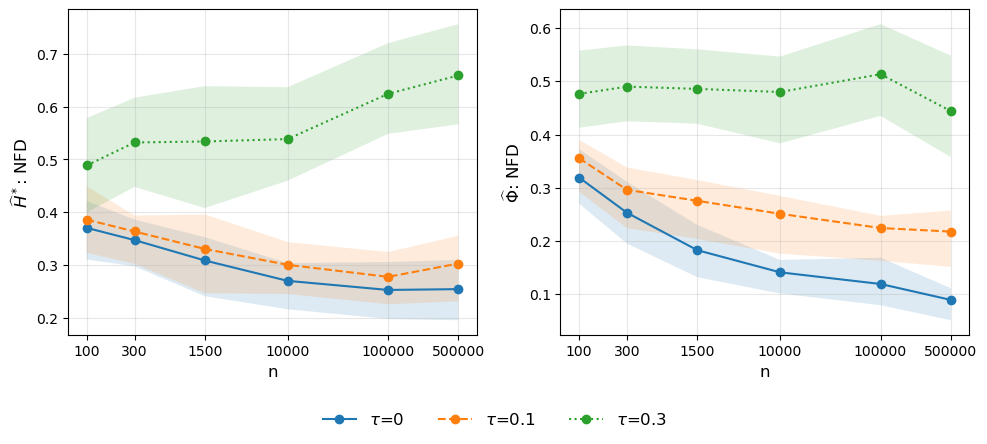

In [37]:
tau_list2 = [0, 0.1, 0.3]
linestyles = ["-", "--", ":"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (prefix, ylabel) in zip(axes, [
    ("H_fro_sourceXray",   r"$\widehat H^*$: NFD"),
    ("C_fro_sourceXray", r"$\widehat \Phi$: NFD"),
]):
    for tau, ls in zip(tau_list2, linestyles):
        sub_mean = (
            df_long[df_long["tau"] == tau]
            .groupby("n")[prefix]
            .mean()
            .reset_index()
            .sort_values("n")
            .rename(columns={prefix: "mean"})
        )
        sub_q = (
            df_long[df_long["tau"] == tau]
            .groupby("n")[prefix]
            .quantile([0.25, 0.75])
            .unstack()
            .reset_index()
            .sort_values("n")
        )
        sub = sub_mean.merge(sub_q, on="n")
        ax.plot(sub["n"], sub["mean"], marker="o", linestyle=ls, label=rf"$\tau$={tau}")
        ax.fill_between(sub["n"], sub[0.25], sub[0.75], alpha=0.15)

    ax.set_xscale("log")
    ax.set_xticks(n_list)
    ax.set_xticklabels(n_list)
    ax.minorticks_off()
    ax.set_xlabel("n", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=len(tau_list2),
    frameon=False, 
    fontsize=12
)

plt.tight_layout()
fig.savefig(outdir/"figure/sourceXray_errors_sims_ar1W_J8K3_NFD.pdf", dpi=150, bbox_inches="tight")
plt.show()


## $\Phi$ in separable case

In [48]:
def plot_phi_comparison(
    Phi,
    Phi_hat,
    title=None,
    cmap="magma",
    figsize=(9, 3),
    savepath=None,
):
    K, J = Phi.shape

    # Determine shared color scale if not provided
    data_min = np.nanmin([Phi.min(), Phi_hat.min()])
    data_max = np.nanmax([Phi.max(), Phi_hat.max()])
    vmin = data_min 
    vmax = data_max 
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin, vmax = 0.0, 1.0  # safe fallback

    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)

    # Left: Truth
    im0 = axes[0].imshow(Phi, aspect='auto', cmap="magma", norm=norm)
    axes[0].set_title(r"True $\Phi$")
    axes[0].set_xlabel("Pollutant")
    axes[0].set_ylabel("Source")

    # Right: Estimation
    im1 = axes[1].imshow(Phi_hat, aspect='auto', cmap="magma", norm=norm)
    axes[1].set_title(r"$\widehat{\Phi}$")
    axes[1].set_xlabel("Pollutant")
    axes[1].set_ylabel("Source")

    # Ticks / labels
    for ax in axes:
        ax.set_xticks(np.arange(J))
        ax.set_yticks(np.arange(K))
        ax.set_xticklabels(np.arange(1, J+1))
        ax.set_yticklabels(np.arange(1, K+1))

    # One shared colorbar (common legend)
    cbar = fig.colorbar(im0, ax=axes.ravel().tolist(),
                        location="right", fraction=0.046, pad=0.04)

    if title is not None:
        fig.suptitle(title)

    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=200)

    plt.show()

In [49]:
tau = 0

In [50]:
n = 300
Phi = results[n][tau]["estimates"]["C"][0,:,:].T
Phi_hat = results[n][tau]["estimates"]["C_hat_sourceXray"][0,:,:].T

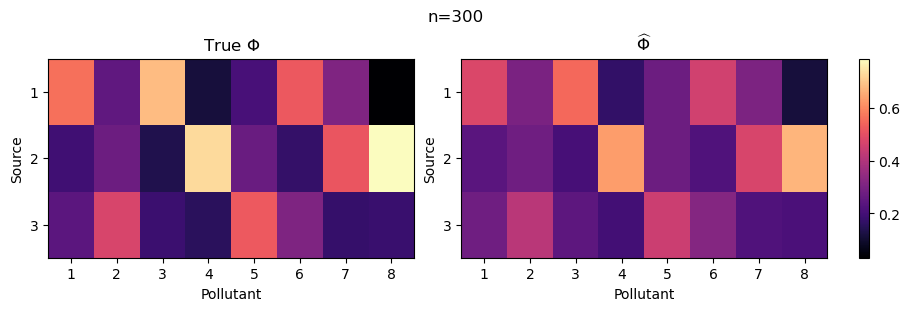

In [ ]:
plot_phi_comparison(
    Phi,
    Phi_hat,
    title=f"n={n}",
    cmap="magma",
    figsize=(9, 3),
    # savepath=outdir/f"figure/sourceXray_errors_sims_ar1W_J8K3_Phi_n{n}.pdf",
)

In [53]:
n = 100000
Phi = results[n][tau]["estimates"]["C"][0,:,:].T
Phi_hat = results[n][tau]["estimates"]["C_hat_sourceXray"][0,:,:].T

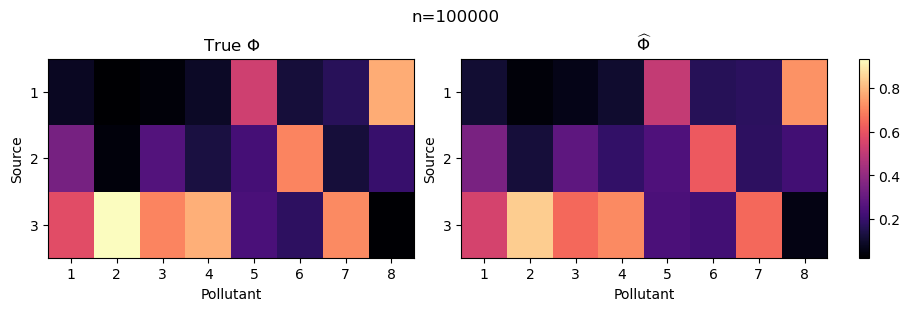

In [ ]:
plot_phi_comparison(
    Phi,
    Phi_hat,
    title=f"n={n}",
    cmap="magma",
    figsize=(9, 3),
    # savepath=outdir/f"figure/sourceXray_errors_sims_ar1W_J8K3_Phi_n{n}.pdf",
)

In [56]:
n = 500000
Phi = results[n][tau]["estimates"]["C"][0,:,:].T
Phi_hat = results[n][tau]["estimates"]["C_hat_sourceXray"][0,:,:].T

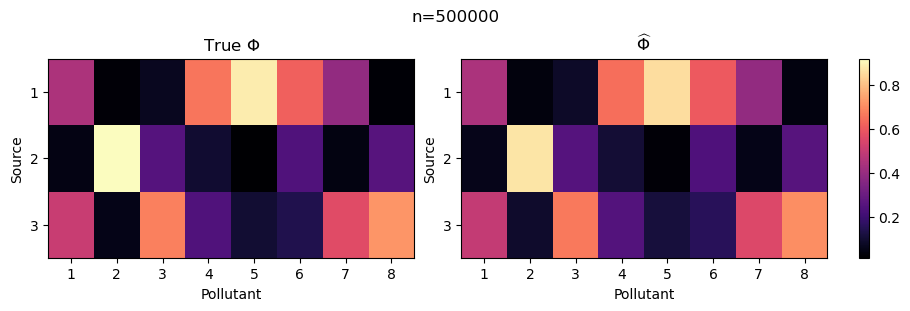

In [ ]:
plot_phi_comparison(
    Phi,
    Phi_hat,
    title=f"n={n}",
    cmap="magma",
    figsize=(9, 3),
    # savepath=outdir/f"figure/sourceXray_errors_sims_ar1W_J8K3_Phi_n{n}.pdf",
)